Question 1: Given a $12 \times 12$ matrix generated by np.arange and then reshaped, use slicing and striding to:
1. Extract a sub-matrix containing every 3rd row and every 4th column.
2. Calculate the sum of the elements in this sub-matrix along axis=1.
3. Reshape the resulting 1D sum array into a column vector.

In [98]:
import numpy as np

a = np.arange(144)
c = a.reshape((12, 12))
print(c)

d = c[0::3, 0::4]
print(d)
e = d.sum(axis=1)

print(e)
f = e.reshape((4, 1))
print(f)


[[  0   1   2   3   4   5   6   7   8   9  10  11]
 [ 12  13  14  15  16  17  18  19  20  21  22  23]
 [ 24  25  26  27  28  29  30  31  32  33  34  35]
 [ 36  37  38  39  40  41  42  43  44  45  46  47]
 [ 48  49  50  51  52  53  54  55  56  57  58  59]
 [ 60  61  62  63  64  65  66  67  68  69  70  71]
 [ 72  73  74  75  76  77  78  79  80  81  82  83]
 [ 84  85  86  87  88  89  90  91  92  93  94  95]
 [ 96  97  98  99 100 101 102 103 104 105 106 107]
 [108 109 110 111 112 113 114 115 116 117 118 119]
 [120 121 122 123 124 125 126 127 128 129 130 131]
 [132 133 134 135 136 137 138 139 140 141 142 143]]
[[  0   4   8]
 [ 36  40  44]
 [ 72  76  80]
 [108 112 116]]
[ 12 120 228 336]
[[ 12]
 [120]
 [228]
 [336]]


Question 2: You have an array $A$ of shape $(5, 2)$ representing the coordinates of 5 points in 2D space. Each coordinate will be represented as (x,y). Use broadcasting to create a $5 \times 5$ distance matrix where the element at $[i, j]$ is the squared Euclidean distance between point $i$ and point $j$.
  $$d_{ij}^2 = (x_i - x_j)^2 + (y_i - y_j)^2$$
- Hint: The shape of the subtraction should be $(5, 1, 2) - (1, 5, 2)$

In [ ]:
import numpy as np
A = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])

#This is also called as the distance matrix
D = np.zeros((5, 5))

for i in range(5):
    for j in range(5):
        #print(f'i: {i}, j: {j} :::: {A[i, j]}')
        xi, yi = A[i]
        xj, yj = A[j]
        D[i, j] = (xi - xj)**2 + (yi - yj)**2

print(A)
print(D)

#Using broadcasting to compute the distance matrix
diff = A[:, None, :] - A[None, :, :]   # shape (5,5,2)
D = np.sum(diff**2, axis=2)            # shape (5,5)

print(A)
print(D)

[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]]
[[  0.   8.  32.  72. 128.]
 [  8.   0.   8.  32.  72.]
 [ 32.   8.   0.   8.  32.]
 [ 72.  32.   8.   0.   8.]
 [128.  72.  32.   8.   0.]]


Question 3:  One Hot Encoding is a "famous technique" used in the Machine Learning projects. 
1. Task : Given an array of labels [0, 2, 1, 0, 1], convert it into a "One-Hot" matrix.
2. Requirements: Create a matrix of shape (num_labels, num_classes) where a 1 is placed in the column corresponding to the label and 0 elsewhere.

Expected Output: One-Hot Matrix

Based on the labels `[0, 2, 1, 0, 1]` and `num_classes = 3`, the generated NumPy array `one_hot` will be a 2D array of floats.
- Class 0 : [1., 0., 0.]
- Class 1 : [0., 1., 0.]
- Class 2 : [0., 0., 1.]
1. Console Print Output
If you print the result in Python, it will look like this:

```python
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]

In [100]:
B = np.array([0, 2, 1, 0, 1])
print(B)

hot_matrix = np.zeros((5, 3))

for i in range(len(B)):
    hot_matrix[i, B[i]] = 1

print(hot_matrix)

[0 2 1 0 1]
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


Question 4: You are given an RGB image "baboon.png" (taken from Set 14 dataset : https://www.kaggle.com/datasets/ll01dm/set-5-14-super-resolution-dataset) which is a multidimensional array of shape (Height, Width, 3) . Here 3 represents the number of channels which in our case now is RGB. 

1. Read the image using `plt.imread` or `imageio.imread`
2. Convert the image to a floating-point data type (`np.float32`) to allow for decimal calculations.
3. Perform Global Min Max Normalization
 $$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

* **$x$**: The original pixel intensity.
* **$x_{min}$**: The minimum intensity found in the image array.
* **$x_{max}$**: The maximum intensity found in the image array.
* **$x_{norm}$**: The resulting floating-point value, where $0.0$ represents the darkest point and $1.0$ represents the brightest.

4. Plot the original and the normalized image side by side
- NOTE : Calculate $x_{min}$ and $x_{max}$ globally across all channels

(480, 500, 3)
0.023529412 0.9607843


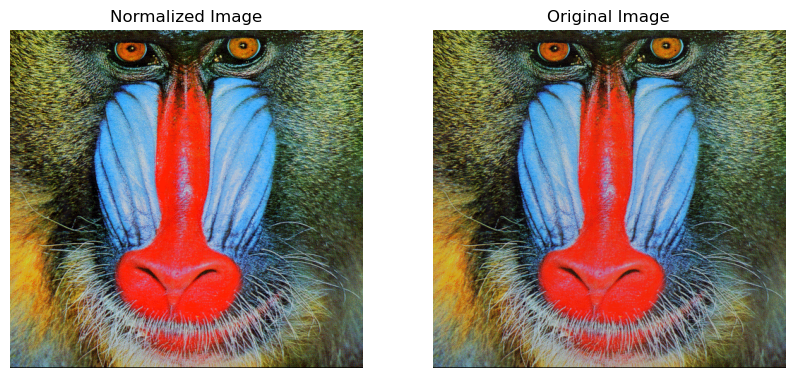

In [102]:
import matplotlib.pyplot as plt
img = plt.imread('data/baboon.png').astype(np.float32)
print(img.shape)

x_max = img.max()
x_min = img.min()
print(x_min, x_max)

normalized_img = (img - x_min) / (x_max - x_min)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(normalized_img)
plt.title('Normalized Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

Question 5: We want to highlight the high intensity red regions and leave the rest of the image as grayscale. The output should highlight the baboon's nose.

1. Use the normalized image created in the previous question
2. Identify those pixels where the Red channel instensity is greater than some **${\lambda}$** (Remember for the normalized image the pixel values range from 0.0 to 1.0). For these pixels keep the original colour.
3. Convert the rest of the pixels to grayscale by setting the R, G, B values to the average of the three original channels.
4. Display the result.

Hint
* Construct the grayscale image by averaging across all R, G and B channels.
* Create a boolean mask 2D array based on the Red channel alone by thresholding
* Apply the grayscale value to all three channels where the mask is True.

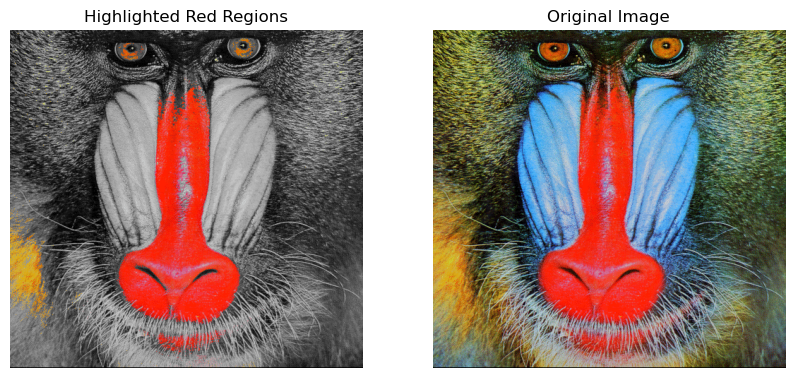

In [139]:
gray = normalized_img.mean(axis=2)
gray_img = np.stack([gray, gray, gray], axis=2)

mask = normalized_img[:,:,0] > 0.8   # example: strong red

output = gray_img.copy()
output[mask] = normalized_img[mask]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(output)
plt.title('Highlighted Red Regions')
plt.axis('off')

# Missing second subplot and plt.show()!
plt.subplot(1, 2, 2)
plt.imshow(normalized_img)
plt.title('Original Image')
plt.axis('off')
plt.show()

Question 6: Write a Python program using the NumPy library to perform the following matrix operations:

1. Create two 3×3 matrices A and B with random integer values.

2. Compute and display the sum and difference of matrices A and B.

3. Perform matrix multiplication of A and B.

4. Find and display the transpose of matrix A.

5. Compute the determinant of matrix A.

6. Check whether matrix A is invertible. If it is invertible, compute and display its inverse.

7. Calculate and display the eigenvalues and eigenvectors of matrix A.

Display all matrices and results clearly using appropriate NumPy functions.

In [140]:
np.random.seed(423)

A = np.random.randint(9, size=(3, 3))
B = np.random.randint(9, size=(3, 3))
print(A)
print(B)

print(f'\n Sum of matrices A + B is :::\n {A + B}')

print(f'\n Differece of matrices A - B is :::\n {A - B}')

print(f'\n Product of matrices A * B is :::\n {A @ B}')

print(f'\n Transpose of matrix A is :::\n {A.T}')

[[8 0 8]
 [6 5 8]
 [6 7 0]]
[[6 5 0]
 [1 2 7]
 [4 0 2]]

 Sum of matrices A + B is :::
 [[14  5  8]
 [ 7  7 15]
 [10  7  2]]

 Differece of matrices A - B is :::
 [[ 2 -5  8]
 [ 5  3  1]
 [ 2  7 -2]]

 Product of matrices A * B is :::
 [[80 40 16]
 [73 40 51]
 [43 44 49]]

 Transpose of matrix A is :::
 [[8 6 6]
 [0 5 7]
 [8 8 0]]


In [62]:
print(f'\n The determinant of matrix A is :::\n {np.linalg.det(A)}')

# A matrix is invertible if its determinant is non-zero. 
# If the determinant is zero, the matrix is singular and does not have an inverse.
if(np.linalg.det(A) != 0):
    print(f'\n The inverse of matrix A is :::\n {np.linalg.inv(A)}')

print(f'\n The eigenvalues and eigenvectors of matrix A are :::\n {np.linalg.eig(A)}')


 The determinant of matrix A is :::
 -351.9999999999999

 The inverse of matrix A is :::
 [[ 0.15909091 -0.15909091  0.11363636]
 [-0.13636364  0.13636364  0.04545455]
 [-0.03409091  0.15909091 -0.11363636]]

 The eigenvalues and eigenvectors of matrix A are :::
 EigResult(eigenvalues=array([15.65210418,  3.59811314, -6.25021732]), eigenvectors=array([[-0.53018482, -0.6198998 , -0.46073979],
       [-0.67950316,  0.70666902, -0.33787822],
       [-0.50712869,  0.3410911 ,  0.82070528]]))


Question 7: Write a Python program using NumPy to perform the following operations:

1. Create a 1-dimensional NumPy array of 12 consecutive integers (from 1 to 12). Reshape this array into a 3×4 matrix (Matrix A).

2. Create another 3×4 matrix (Matrix B) with random integers between 10 and 20. Concatenate the two matrices (A and B) vertically and horizontally, and display the results.

3. Stack the two matrices (A and B) along a new third axis using np.stack. Display the resulting 3-dimensional array.

4. Split the vertically concatenated matrix into three equal parts vertically.

5. Split the horizontally concatenated matrix into two equal parts horizontally.

6. Display all the resulting arrays.

In [105]:
P = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
print(P)

A = P.reshape((3, 4))
print(A)

np.random.seed(423)
B = np.random.randint(10, 21, size=(3, 4))
print(B)

V = np.vstack((A, B))
H = np.hstack((A, B))

print(f'\n Concatenation of matrices A & B vertically is :::\n {V}')

print(f'\n Concatenation of matrices A & B horizontally is :::\n {H}')

[ 1  2  3  4  5  6  7  8  9 10 11 12]
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[[18 20 10 20]
 [18 16 15 18]
 [16 17 10 19]]

 Concatenation of matrices A & B vertically is :::
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [18 20 10 20]
 [18 16 15 18]
 [16 17 10 19]]

 Concatenation of matrices A & B horizontally is :::
 [[ 1  2  3  4 18 20 10 20]
 [ 5  6  7  8 18 16 15 18]
 [ 9 10 11 12 16 17 10 19]]


In [89]:
C = np.stack((A, B), axis=2)
print(C.shape)
print(f'\n Stacking A and B :::\n {C}')

print(f'Splitting the vertically stacked matrix V into 3 parts :::\n {np.split(V, 3)}')

print(f'Splitting the horizontally stacked matrix H into 2 parts :::\n {np.split(H, 2, axis=1)}')

(3, 4, 2)

 Stacking A and B :::
 [[[ 1 18]
  [ 2 20]
  [ 3 10]
  [ 4 20]]

 [[ 5 18]
  [ 6 16]
  [ 7 15]
  [ 8 18]]

 [[ 9 16]
  [10 17]
  [11 10]
  [12 19]]]
Splitting the vertically stacked matrix V into 3 parts :::
 [array([[1, 2, 3, 4],
       [5, 6, 7, 8]]), array([[ 9, 10, 11, 12],
       [18, 20, 10, 20]]), array([[18, 16, 15, 18],
       [16, 17, 10, 19]])]
Splitting the horizontally stacked matrix H into 2 parts :::
 [array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]]), array([[18, 20, 10, 20],
       [18, 16, 15, 18],
       [16, 17, 10, 19]])]


Question 8: Write a Python program to generate a collection of random points inside the unit cube defined by 
0 ≤ 𝑥 ≤ 1,  0≤y≤1, and 0≤z≤1. Use these points to create a 3D scatter plot that visualizes the interior of the unit cube. Use appropriate Python libraries such as NumPy for random point generation and Matplotlib for 3D plotting. Label the axes and ensure the cube boundaries are properly represented.

Text(0.5, 0, 'Z')

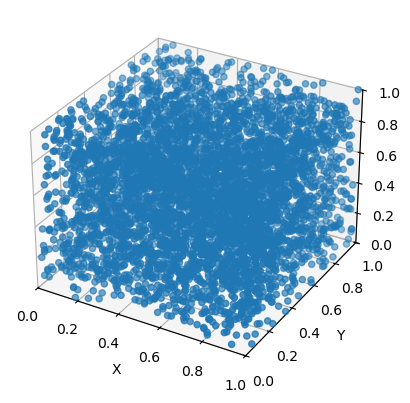

In [96]:
x = np.random.rand(5000)
y = np.random.rand(5000)
z = np.random.rand(5000)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

Question 9: Write a Python program using NumPy to perform linear and polynomial least squares fitting on a dataset stored in a CSV file.

The program should perform the following tasks:

1. Load the dataset: Use np.loadtxt() to read a CSV file (e.g., Salary_Data.csv) containing two columns: x (independent variable) and y (dependent variable).

2. Linear Least Squares Fit: Compute the best-fit line y=mx+c using np.linalg.lstsq(), where x: Years of Experience, y: Salary

3. Display the slope (m) and intercept (c). Calculate and display the residuals.

4. Polynomial Fit: Fit a quadratic polynomial (degree 2) to the same data using np.polyfit().

5. Display the polynomial coefficients. Calculate and display the residuals.

6. Calculate the mean and standard deviation of residuals for both linear and polynomial fits.

7. Plot the original data points. Plot the linear fit and polynomial fit on the same graph with appropriate labels, colors, and a legend.

8. Create a plot for residuals to compare the residuals of the linear and polynomial models. Include a horizontal line at zero to visualize deviations.

Slope (m): 9449.962321455072
Intercept (c): 25792.20019866871
Polynomial coefficients: [1.63925663e+01 9.25928389e+03 2.62149327e+04]
Linear residual mean: 8.48861721654733e-12
Linear residual std: 5592.043608760661
Polynomial residual mean: 2.522331972916921e-11
Polynomial residual std: 5590.841479683288


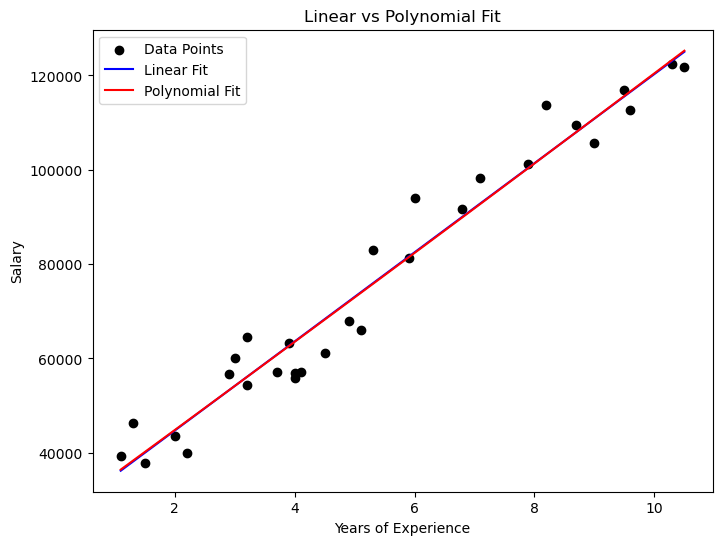

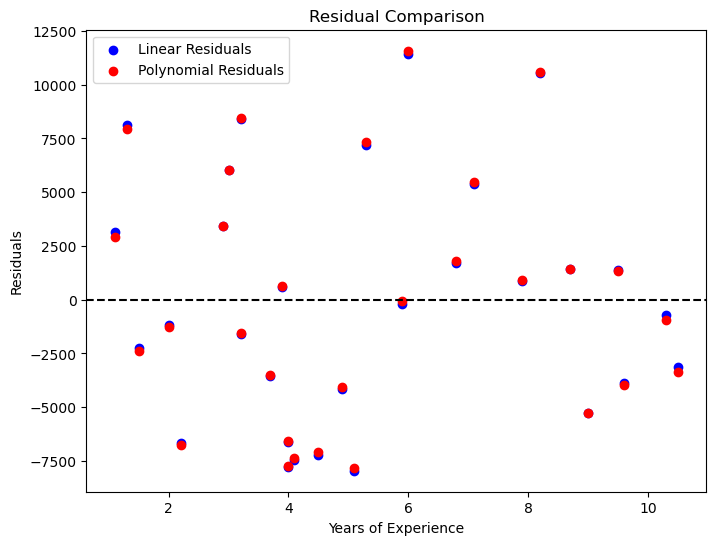

In [127]:
salary_data = np.loadtxt('data/Salary_Data.csv', skiprows=1, delimiter=',', unpack=True)
x = salary_data[0]  # Years of Experience
y = salary_data[1]  # Salary

# 2. Linear Least Squares using np.linalg.lstsq()
A = np.vstack((x, np.ones_like(x))).T
slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]

print(f"Slope (m): {slope}")
print(f"Intercept (c): {intercept}")

# 3. Calculate residuals for linear fit
y_pred_linear = slope * x + intercept
residual_linear = y - y_pred_linear

# 4. Polynomial Fit (degree 2)
coeff_poly = np.polyfit(x, y, deg=2)
print("Polynomial coefficients:", coeff_poly)

p_poly = np.poly1d(coeff_poly)
y_pred_poly = p_poly(x)

# 5. Polynomial residuals
residuals_poly = y - y_pred_poly

# 6. Mean and Standard Deviation of residuals
print("Linear residual mean:", np.mean(residual_linear))
print("Linear residual std:", np.std(residual_linear))

print("Polynomial residual mean:", np.mean(residuals_poly))
print("Polynomial residual std:", np.std(residuals_poly))

# Linear polynomial object (for plotting)
p_linear = np.poly1d([slope, intercept])

# Smooth x values for plotting curves
x_line = np.linspace(min(x), max(x), 100)

# 7. Plot original data and fitted models
plt.figure(figsize=(8,6))

plt.scatter(x, y, color="black", label="Data Points")
plt.plot(x_line, p_linear(x_line), color="blue", label="Linear Fit")
plt.plot(x_line, p_poly(x_line), color="red", label="Polynomial Fit")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear vs Polynomial Fit")
plt.legend()

plt.show()

# 8. Residual comparison plot
plt.figure(figsize=(8,6))

plt.scatter(x, residual_linear, color="blue", label="Linear Residuals")
plt.scatter(x, residuals_poly, color="red", label="Polynomial Residuals")

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Years of Experience")
plt.ylabel("Residuals")
plt.title("Residual Comparison")
plt.legend()

plt.show()